In [18]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [19]:
CSV_PATH = "weather.csv" 
FEATURE_COLS = ["MeanTemp", "MaxTemp", "MinTemp"]  # features to use
TARGET_COL = "MeanTemp"     # next-day prediction target
WINDOW = 30
BATCH_SIZES = [16, 32]
EPOCHS = 30
TEST_RATIO = 0.2
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [20]:
def create_multi_sequences(features, target, window):
    X, y = [], []
    total = len(features)
    for i in range(total - window):
        X.append(features[i:i+window, :])   # past 30 days
        y.append(target[i+window])          # next-day temp
    return np.array(X), np.array(y).reshape(-1, 1)

In [21]:
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH, low_memory=False)

In [22]:
for col in FEATURE_COLS + [TARGET_COL]:
    if col not in df.columns:
        raise KeyError(f"Column '{col}' missing. Available: {df.columns.tolist()}")

In [23]:
df = df[FEATURE_COLS].dropna().astype(float)

In [24]:
features = df[FEATURE_COLS].values
target = df[[TARGET_COL]].values

In [25]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
features_scaled = scaler_X.fit_transform(features)
target_scaled = scaler_y.fit_transform(target)

In [26]:
X_all, y_all = create_multi_sequences(features_scaled, target_scaled, WINDOW)
print(f"X_all shape: {X_all.shape}, y_all shape: {y_all.shape}")

X_all shape: (119010, 30, 3), y_all shape: (119010, 1)


In [27]:
split_idx = int(len(X_all) * (1 - TEST_RATIO))
X_train, X_test = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

In [28]:
def build_model(window, n_features):
    model = Sequential([
        Input(shape=(window, n_features)),  # <- Explicit Input layer
        SimpleRNN(64),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

In [29]:
results = {}
for bs in BATCH_SIZES:
    print(f"\nTraining with batch size = {bs}")
    model = build_model(WINDOW, X_train.shape[2])
    history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=bs,
                        validation_data=(X_test, y_test), verbose=2)

    # Predictions
    y_pred_scaled = model.predict(X_test, batch_size=bs)
    y_test_orig = scaler_y.inverse_transform(y_test)
    y_pred_orig = scaler_y.inverse_transform(y_pred_scaled)

    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    rmse = math.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    print(f"Batch {bs} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")

    results[bs] = {"mae": mae, "rmse": rmse,
                   "y_test": y_test_orig.reshape(-1),
                   "y_pred": y_pred_orig.reshape(-1)}


Training with batch size = 16
Epoch 1/30
5951/5951 - 20s - 3ms/step - loss: 8.5324e-04 - val_loss: 5.2407e-04
Epoch 2/30
5951/5951 - 26s - 4ms/step - loss: 6.6569e-04 - val_loss: 5.0852e-04
Epoch 3/30
5951/5951 - 32s - 5ms/step - loss: 6.4626e-04 - val_loss: 4.9992e-04
Epoch 4/30
5951/5951 - 17s - 3ms/step - loss: 6.3207e-04 - val_loss: 5.2949e-04
Epoch 5/30
5951/5951 - 17s - 3ms/step - loss: 6.2399e-04 - val_loss: 5.4355e-04
Epoch 6/30
5951/5951 - 17s - 3ms/step - loss: 6.2328e-04 - val_loss: 5.6643e-04
Epoch 7/30
5951/5951 - 17s - 3ms/step - loss: 6.1322e-04 - val_loss: 5.7191e-04
Epoch 8/30
5951/5951 - 17s - 3ms/step - loss: 6.1197e-04 - val_loss: 5.4676e-04
Epoch 9/30
5951/5951 - 17s - 3ms/step - loss: 6.0834e-04 - val_loss: 5.4310e-04
Epoch 10/30
5951/5951 - 17s - 3ms/step - loss: 6.0663e-04 - val_loss: 5.2624e-04
Epoch 11/30
5951/5951 - 18s - 3ms/step - loss: 6.0571e-04 - val_loss: 5.1202e-04
Epoch 12/30
5951/5951 - 19s - 3ms/step - loss: 6.0513e-04 - val_loss: 4.9741e-04
Epoch 

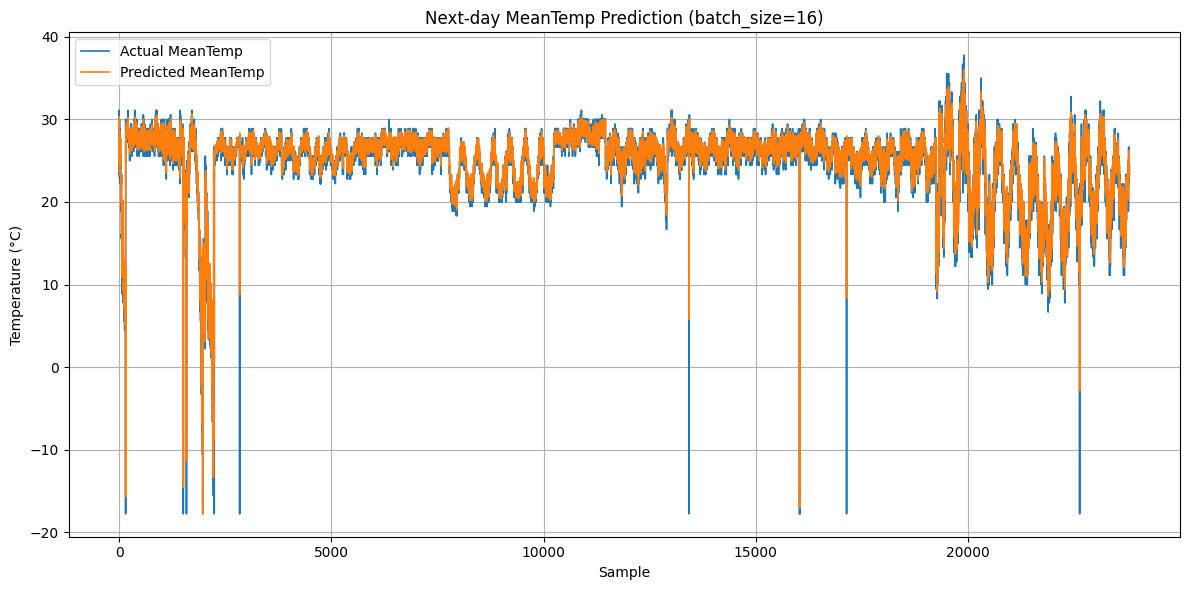

In [30]:
bs_plot = 16
if bs_plot in results:
    y_test_orig = results[bs_plot]["y_test"]
    y_pred_orig = results[bs_plot]["y_pred"]
    plt.figure(figsize=(12,6))
    plt.plot(y_test_orig, label="Actual MeanTemp", linewidth=1.2)
    plt.plot(y_pred_orig, label="Predicted MeanTemp", linewidth=1.2)
    plt.title(f"Next-day MeanTemp Prediction (batch_size={bs_plot})")
    plt.xlabel("Sample")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [31]:
for bs in BATCH_SIZES:
    print(f"Batch {bs}: MAE={results[bs]['mae']:.4f}, RMSE={results[bs]['rmse']:.4f}")

Batch 16: MAE=0.8907, RMSE=1.6997
Batch 32: MAE=0.9651, RMSE=1.7237
